<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Removing Duplicates**


Estimated time needed: **30** minutes


## Introduction


In this lab, you will focus on data wrangling, an important step in preparing data for analysis. Data wrangling involves cleaning and organizing data to make it suitable for analysis. One key task in this process is removing duplicate entries, which are repeated entries that can distort analysis and lead to inaccurate conclusions.  


## Objectives


In this lab you will perform the following:


1. Identify duplicate rows  in the dataset.
2. Use suitable techniques to remove duplicate rows and verify the removal.
3. Summarize how to handle missing values appropriately.
4. Use ConvertedCompYearly to normalize compensation data.
   


### Install the Required Libraries


In [1]:
!pip install pandas

### Step 1: Import Required Libraries


In [2]:
import pandas as pd

### Step 2: Load the Dataset into a DataFrame



load the dataset using pd.read_csv()


In [3]:
# Define the URL of the dataset
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

# Load the dataset into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows to ensure it loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

**Note: If you are working on a local Jupyter environment, you can use the URL directly in the <code>pandas.read_csv()</code>  function as shown below:**



#df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")


### Step 3: Identifying Duplicate Rows


**Task 1: Identify Duplicate Rows**
  1. Count the number of duplicate rows in the dataset.
  2. Display the first few duplicate rows to understand their structure.


In [7]:
## Write your code here
# count number of duplicate rows in dataframe
duplicate_count = df.duplicated().sum()
print(f'The number of duplicate rows in the dataset is {duplicate_count}')

The number of duplicate rows in the dataset is 0


### Step 4: Removing Duplicate Rows


**Task 2: Remove Duplicates**
   1. Remove duplicate rows from the dataset using the drop_duplicates() function.
2. Verify the removal by counting the number of duplicate rows after removal .


In [8]:
## Write your code here
#drop duplicates using drop_duplicates() function
df.drop_duplicates(inplace=True) #inplace=true keeps it in the same dataframe
duplicate_count = df.duplicated().sum()
print(f'The number of duplicate rows in the dataset is {duplicate_count}')


The number of duplicate rows in the dataset is 0


### Step 5: Handling Missing Values


**Task 3: Identify and Handle Missing Values**
   1. Identify missing values for all columns in the dataset.
   2. Choose a column with significant missing values (e.g., EdLevel) and impute with the most frequent value.


In [20]:
## Write your code here
import numpy as np
missing_values = df.isna().sum()
print(missing_values.to_string())

#Impute EdLevel with most frequent value
ed_level_mode = df['EdLevel'].mode()[0] #define the most frequent value
df['EdLevel']=df['EdLevel'].fillna(ed_level_mode) #fills the na's with most frequent value for EdLevel column
print(f'Number of missing values for EdLevel: {df['EdLevel'].isna().sum()}') #checks for updated number of na's in EdLevel column


ResponseId                            0
MainBranch                            0
Age                                   0
Employment                            0
RemoteWork                        10631
Check                                 0
CodingActivities                  10971
EdLevel                               0
LearnCode                          4949
LearnCodeOnline                   16200
TechDoc                           24540
YearsCode                          5568
YearsCodePro                      13827
DevType                            5992
OrgSize                           17957
PurchaseInfluence                 18031
BuyNewTool                        20256
BuildvsBuy                        22079
TechEndorse                       21769
Country                            6507
Currency                          18753
CompTotal                         31697
LanguageHaveWorkedWith             5692
LanguageWantToWorkWith             9685
LanguageAdmired                   14565


### Step 6: Normalizing Compensation Data


**Task 4: Normalize Compensation Data Using ConvertedCompYearly**
   1. Use the ConvertedCompYearly column for compensation analysis as the normalized annual compensation is already provided.
   2. Check for missing values in ConvertedCompYearly and handle them if necessary.


In [29]:
## Write your code here

#check for missing values in compensation column
missing_comp = df['ConvertedCompYearly'].isna().sum()
print(f'There are {missing_comp} missing values for ConvertedCompYearly')

#calculate median compensation to fill na's
median_comp = df['ConvertedCompYearly'].median()

df['ConvertedCompYearly']=df['ConvertedCompYearly'].fillna(median_comp) #fills the na's with most frequent value for ConvertedCompYearly column
print(f'Number of missing values for ConvertedCompYearly: {df['ConvertedCompYearly'].isna().sum()}') #checks for updated number of na's in ConvertedCompYearly column


There are 42002 missing values for ConvertedCompYearly
Number of missing values for ConvertedCompYearly: 0


### Step 7: Summary and Next Steps


**In this lab, you focused on identifying and removing duplicate rows.**

- You handled missing values by imputing the most frequent value in a chosen column.

- You used ConvertedCompYearly for compensation normalization and handled missing values.

- For further analysis, consider exploring other columns or visualizing the cleaned dataset.


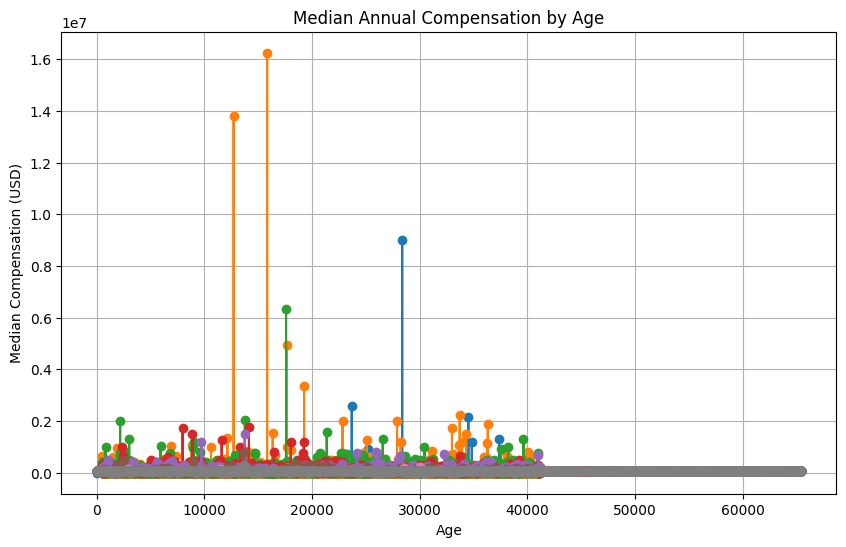

In [31]:
## Write your code here
import matplotlib.pyplot as plt

# 1. Group by Age and calculate the median compensation for each age
# This creates a clean trend line
age_comp_trend = df.groupby('Age')['ConvertedCompYearly']

# 2. Plot the line graph
age_comp_trend.plot(kind='line', figsize=(10, 6), marker='o')

# 3. Add labels and title
plt.title('Median Annual Compensation by Age')
plt.xlabel('Age')
plt.ylabel('Median Compensation (USD)')
plt.grid(True)
plt.show()

<!--
## Change Log

|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11-05|1.2|Madhusudhan Moole|Updated lab|
|2024-09-24|1.1|Madhusudhan Moole|Updated lab|
|2024-09-23|1.0|Raghul Ramesh|Created lab|

--!>


Copyright © IBM Corporation. All rights reserved.
